In [18]:
# =========================
# Cell 1: Environment + Run Config (Reproducible)
# =========================

import os, random, time
import numpy as np

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

# ---- Torch checks ----
try:
    import torch
    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("gpu:", torch.cuda.get_device_name(0))
        print("cuda:", torch.version.cuda)
        # Optional: speed up convs
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
except Exception as e:
    print("Torch import failed:", e)

# ---- Run config (LOCKED v1) ----
CFG = {
    "seed": SEED,
    "num_frames": 16,
    "input_size": 224,
    "batch_size": 20,  # DFDC: (5R,5F) + DF: (5R,5F)
    "num_workers": 4,  # we will tune later (often 4-8)
    "max_epochs": 25,
    "min_epochs": 8,
    "early_stop_patience": 5,

    # temporal sampling
    "temporal_strides": [1, 2, 4],  # sampled uniformly

    # augmentation probabilities (finalized for RTX6000 Ada)
    "p_compress": 0.60,
    "p_res": 0.70,
    "p_noise": 0.50,
    "p_blur": 0.35,
    "p_cam_jitter": 0.40,
    "p_cutout": 0.25,
    "p_freq_drop": 0.25,
    "p_face_drop": 0.20,  # only if we implement bbox-based face dropout

    # domain adversarial (GRL)
    "grl_lambda_max": 0.05,  # ramp schedule later

    # regularization
    "label_smoothing": 0.05,
}

print("\n===== RUN BANNER =====")
for k in ["batch_size","num_frames","input_size","max_epochs","grl_lambda_max","label_smoothing"]:
    print(f"{k}: {CFG[k]}")
print("======================")

torch: 2.7.0+cu126
cuda available: True
gpu: NVIDIA RTX A5000
cuda: 12.6

===== RUN BANNER =====
batch_size: 20
num_frames: 16
input_size: 224
max_epochs: 25
grl_lambda_max: 0.05
label_smoothing: 0.05


In [14]:
# =========================
# Cell 2: Load metadata + inspect
# =========================

import pandas as pd

META_PATH = "/home/unified_training_metadata.csv"
df = pd.read_csv(META_PATH)

print("Total rows:", len(df))
display(df.head())

print("\nUnique splits:", df['split'].unique())
print("Unique domains:", df['domain'].unique())
print("Unique labels:", df['class_label'].unique())

print("\nCounts by split:")
print(df['split'].value_counts())

print("\nCounts by domain & label:")
print(df.groupby(['domain','class_label']).size())

print("\nCounts by split & domain:")
print(df.groupby(['split','domain']).size())

Total rows: 18966


,path,split,domain,class_label,sampler_group
0,/home/DFDC_dataset/fake/qyyebirxwe.mp4,train,0,1,1
1,/home/DFDC_dataset/fake/ntjlknlcvn.mp4,val,0,1,1
2,/home/DFDC_dataset/fake/qivpypiwlp.mp4,train,0,1,1
3,/home/DFDC_dataset/fake/lpkgabskbw.mp4,train,0,1,1
4,/home/DFDC_dataset/fake/vctemjbusz.mp4,val,0,1,1



Unique splits: ['train' 'val' 'test']
Unique domains: [0 1]
Unique labels: [1 0]

Counts by split:
split
train    15433
val       2734
test       799
Name: count, dtype: int64

Counts by domain & label:
domain  class_label
0       0              1354
        1              7803
1       0              7829
        1              1980
dtype: int64

Counts by split & domain:
split  domain
test   0          799
train  0         7509
       1         7924
val    0          849
       1         1885
dtype: int64


In [15]:
# =========================
# Cell 3: Build index pools
# =========================

train_df = df[df.split == "train"].reset_index(drop=True)
val_df   = df[df.split == "val"].reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

def build_pools(dataframe):
    pools = {}
    for domain in sorted(dataframe.domain.unique()):
        for label in [0,1]:
            key = (domain, label)
            pools[key] = dataframe[
                (dataframe.domain == domain) &
                (dataframe.class_label == label)
            ].index.tolist()
            print(f"Domain {domain} Label {label}: {len(pools[key])} samples")
    return pools

train_pools = build_pools(train_df)
val_pools   = build_pools(val_df)

Train size: 15433
Val size: 2734
Domain 0 Label 0: 1083 samples
Domain 0 Label 1: 6426 samples
Domain 1 Label 0: 6296 samples
Domain 1 Label 1: 1628 samples
Domain 0 Label 0: 135 samples
Domain 0 Label 1: 714 samples
Domain 1 Label 0: 1533 samples
Domain 1 Label 1: 352 samples


In [16]:
# =========================
# Cell 4: Balanced Multi-Domain Sampler
# =========================

import random
from torch.utils.data import Sampler

class BalancedMultiDomainBatchSampler(Sampler):
    """
    Produces batches with fixed composition:
        DFDC: 5 real + 5 fake
        DeeperForensics: 5 real + 5 fake
    """

    def __init__(self, train_df, train_pools, batch_size=20):
        self.df = train_df
        self.pools = train_pools
        self.batch_size = batch_size
        
        # Fixed composition per batch
        self.per_group = 5  # per (domain, label)
        self.groups = [
            (0,0),  # DFDC real
            (0,1),  # DFDC fake
            (1,0),  # DF real
            (1,1)   # DF fake
        ]
        
        # Rough epoch length
        self.steps_per_epoch = len(train_df) // batch_size

        print("Steps per epoch:", self.steps_per_epoch)

    def __len__(self):
        return self.steps_per_epoch

    def sample_from_pool(self, pool, k):
        # sample WITH replacement (important for balancing)
        return random.choices(pool, k=k)

    def __iter__(self):
        for _ in range(self.steps_per_epoch):
            batch_indices = []

            for group in self.groups:
                pool = self.pools[group]
                batch_indices += self.sample_from_pool(pool, self.per_group)

            random.shuffle(batch_indices)
            yield batch_indices

In [19]:
# =========================
# Cell 5: Create sampler instance
# =========================

batch_sampler = BalancedMultiDomainBatchSampler(
    train_df=train_df,
    train_pools=train_pools,
    batch_size=CFG["batch_size"]
)

Steps per epoch: 771


In [20]:
!pip install opencv-python


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [21]:
# =========================
# cell 7
# Efficient video frame reader (NO full video loading)
# =========================

def read_video_frames(video_path, num_frames=16, strides=[1,2,4]):
    """
    Memory-safe frame sampling.
    We DO NOT load full video into RAM.
    """

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # choose stride mode
    stride = random.choice(strides)
    clip_len = num_frames * stride

    if total_frames >= clip_len:
        start = random.randint(0, total_frames - clip_len)
        frame_ids = [start + i*stride for i in range(num_frames)]
    else:
        frame_ids = np.linspace(0, total_frames-1, num_frames).astype(int)

    frames = []
    current_frame = 0
    target_idx = 0

    while cap.isOpened() and target_idx < len(frame_ids):
        ret, frame = cap.read()
        if not ret:
            break

        if current_frame == frame_ids[target_idx]:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
            target_idx += 1

        current_frame += 1

    cap.release()

    # safety fallback (rare)
    if len(frames) < num_frames:
        frames += [frames[-1]] * (num_frames - len(frames))

    return frames

In [22]:
# =========================
# Cell 8: Temporal sampling function
# =========================

import random
import numpy as np

def temporal_sample(frames, num_frames=16, strides=[1,2,4]):
    """
    Multi-scale temporal sampling.
    Always returns exactly 16 frames.
    """
    
    total = len(frames)
    stride = random.choice(strides)
    clip_len = num_frames * stride

    if total >= clip_len:
        start = random.randint(0, total - clip_len)
        indices = [start + i*stride for i in range(num_frames)]
    else:
        # fallback if video short
        indices = np.linspace(0, total-1, num_frames).astype(int)

    sampled = [frames[i] for i in indices]
    return sampled

In [23]:
# =========================
# Cell 9: Video Dataset
# =========================

class DeepfakeVideoDataset(Dataset):
    def __init__(self, dataframe, cfg):
        self.df = dataframe
        self.cfg = cfg
        self.num_frames = cfg["num_frames"]
        self.strides = cfg["temporal_strides"]
        self.size = cfg["input_size"]

    def __len__(self):
        return len(self.df)

    def resize_frame(self, frame):
        frame = cv2.resize(frame, (self.size, self.size))
        frame = frame / 255.0
        frame = np.transpose(frame, (2,0,1))  # HWC → CHW
        return frame.astype(np.float32)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        path = row.path
        label = row.class_label
        domain = row.domain

        frames = read_video_frames(path, self.num_frames, self.strides)

        frames = [self.resize_frame(f) for f in frames]
        video = np.stack(frames)  # T,C,H,W

        return torch.tensor(video), torch.tensor(label), torch.tensor(domain)

In [25]:
# =========================
# Cell 10: Dataset sanity test
# =========================

train_dataset = DeepfakeVideoDataset(train_df, CFG)

video, label, domain = train_dataset[0]

print("Video tensor shape:", video.shape)  # expect [16,3,224,224]
print("Label:", label.item())
print("Domain:", domain.item())

Video tensor shape: torch.Size([16, 3, 224, 224])
Label: 1
Domain: 0


In [26]:
# =========================
# Cell 11: Validation dataset
# =========================

val_dataset = DeepfakeVideoDataset(val_df, CFG)

print("Train videos:", len(train_dataset))
print("Val videos:", len(val_dataset))

Train videos: 15433
Val videos: 2734


In [27]:
# =========================
# Cell 12: DataLoaders
# =========================

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_sampler=batch_sampler,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

In [28]:
# =========================
# Cell 13: Dataloader sanity test
# =========================

videos, labels, domains = next(iter(train_loader))

print("Batch video shape:", videos.shape)
print("Batch labels shape:", labels.shape)
print("Batch domains shape:", domains.shape)

print("\nBatch composition:")
import pandas as pd
tmp = pd.DataFrame({
    "domain": domains.numpy(),
    "label": labels.numpy()
})
print(tmp.groupby(["domain","label"]).size())

Batch video shape: torch.Size([20, 16, 3, 224, 224])
Batch labels shape: torch.Size([20])
Batch domains shape: torch.Size([20])

Batch composition:
domain  label
0       0        5
        1        5
1       0        5
        1        5
dtype: int64


In [29]:
!pip install timm -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [30]:
!pip install scikit-learn -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [31]:
import torch
import torch.nn as nn
from torchvision.models.video import swin3d_s, Swin3D_S_Weights

# =========================
# 1️⃣ Recreate GRL
# =========================

from torch.autograd import Function

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

def grad_reverse(x, lambd=1.0):
    return GradReverse.apply(x, lambd)


# =========================
# 2️⃣ Recreate Model Class
# =========================

class DeepfakeDetector(nn.Module):
    def __init__(self, backbone, grl_lambda=0.0):
        super().__init__()
        self.backbone = backbone
        self.grl_lambda = grl_lambda

        feat_dim = backbone.num_features

        self.cls_head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 1)
        )

        self.domain_head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 2)
        )

    def forward(self, x):
        # x: (B,T,C,H,W)
        x = x.permute(0, 2, 1, 3, 4).contiguous()  # → (B,C,T,H,W)

        feats = self.backbone(x)

        logits = self.cls_head(feats).squeeze(1)

        rev_feats = grad_reverse(feats, self.grl_lambda)
        domain_logits = self.domain_head(rev_feats)

        return logits, domain_logits


# =========================
# 3️⃣ Recreate Backbone
# =========================

weights = Swin3D_S_Weights.KINETICS400_V1
backbone = swin3d_s(weights=weights)

# Remove original head
backbone.head = nn.Identity()


# =========================
# 4️⃣ Create Model Instance
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepfakeDetector(backbone, grl_lambda=0.0)
model = model.to(device)


# =========================
# 5️⃣ Load Saved Weights
# =========================

state_dict = torch.load("best_model.pth", map_location=device)
model.load_state_dict(state_dict)

model.eval()

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [32]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def evaluate_domain(model, dataloader, target_domain, device="cuda"):
    model.eval()

    all_logits = []
    all_labels = []

    for videos, labels, domains in dataloader:
        videos = videos.to(device)
        labels = labels.to(device)
        domains = domains.to(device)

        # Filter only selected domain
        mask = (domains == target_domain)
        if mask.sum() == 0:
            continue

        videos = videos[mask]
        labels = labels[mask]

        logits, _ = model(videos)

        all_logits.extend(logits.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # Convert to numpy
    all_logits = np.array(all_logits)
    all_labels = np.array(all_labels)

    probs = 1 / (1 + np.exp(-all_logits))

    auc = roc_auc_score(all_labels, probs)
    preds = (probs > 0.5).astype(int)
    acc = (preds == all_labels).mean()

    return auc, acc

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dfdc_auc, dfdc_acc = evaluate_domain(model, val_loader, target_domain=0, device=device)
df_auc, df_acc     = evaluate_domain(model, val_loader, target_domain=1, device=device)

In [34]:
print("\n📋 DATASET COMPARISON TABLE")
print("Dataset Source                   | AUC        | Accuracy  ")
print("------------------------------------------------------------")
print(f"DFDC (Organic/Noisy)             | {dfdc_auc:.4f} | {dfdc_acc:.4f}")
print(f"DeeperForensics (High-Fidelity)  | {df_auc:.4f} | {df_acc:.4f}")


📋 DATASET COMPARISON TABLE
Dataset Source                   | AUC        | Accuracy  
------------------------------------------------------------
DFDC (Organic/Noisy)             | 0.9641 | 0.8657
DeeperForensics (High-Fidelity)  | 1.0000 | 0.9989


In [35]:
print("\n📋 DATASET COMPARISON TABLE")
print("-" * 60)
print(f"{'Dataset Source':35s} | {'AUC':8s} | {'Accuracy':8s}")
print("-" * 60)
print(f"{'DFDC (Organic/Noisy)':35s} | {dfdc_auc:8.4f} | {dfdc_acc:8.4f}")
print(f"{'DeeperForensics (High-Fidelity)':35s} | {df_auc:8.4f} | {df_acc:8.4f}")
print("-" * 60)


📋 DATASET COMPARISON TABLE
------------------------------------------------------------
Dataset Source                      | AUC      | Accuracy
------------------------------------------------------------
DFDC (Organic/Noisy)                |   0.9641 |   0.8657
DeeperForensics (High-Fidelity)     |   1.0000 |   0.9989
------------------------------------------------------------


In [36]:
import torch
import numpy as np

@torch.no_grad()
def failure_analysis(model, dataloader, device="cuda"):
    model.eval()

    total_errors = 0
    dfdc_errors = 0
    df_errors = 0

    total_samples = 0
    dfdc_samples = 0
    df_samples = 0

    for videos, labels, domains in dataloader:
        videos = videos.to(device)
        labels = labels.to(device)
        domains = domains.to(device)

        logits, _ = model(videos)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()

        errors = (preds != labels)

        # Count totals
        total_errors += errors.sum().item()
        total_samples += labels.size(0)

        # Domain-specific
        dfdc_mask = (domains == 0)
        df_mask   = (domains == 1)

        dfdc_errors += (errors & dfdc_mask).sum().item()
        df_errors   += (errors & df_mask).sum().item()

        dfdc_samples += dfdc_mask.sum().item()
        df_samples   += df_mask.sum().item()

    return {
        "total_errors": total_errors,
        "total_samples": total_samples,
        "dfdc_errors": dfdc_errors,
        "dfdc_samples": dfdc_samples,
        "df_errors": df_errors,
        "df_samples": df_samples
    }

In [37]:
results = failure_analysis(model, val_loader, device=device)

total_errors = results["total_errors"]
dfdc_errors  = results["dfdc_errors"]
df_errors    = results["df_errors"]

dfdc_error_rate = dfdc_errors / results["dfdc_samples"]
df_error_rate   = df_errors / results["df_samples"]

In [38]:
print("\n🔬 FAILURE SOURCE ANALYSIS")
print("------------------------------")
print(f"Total Errors: {total_errors}")
print(f"Errors from DFDC (Domain 0): {dfdc_errors} "
      f"({dfdc_error_rate:.4f})")
print(f"Errors from DeeperForensics (Domain 1): {df_errors} "
      f"({df_error_rate:.4f})")


🔬 FAILURE SOURCE ANALYSIS
------------------------------
Total Errors: 119
Errors from DFDC (Domain 0): 117 (0.1378)
Errors from DeeperForensics (Domain 1): 2 (0.0011)


In [39]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 24.7 MB/s eta 0:00:00:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler

In [40]:
import torch.nn as nn

class FakeOnlyWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        logits, _ = self.model(x)
        return logits.unsqueeze(1)  # shape (B,1)

In [41]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import numpy as np

In [42]:
target_layers = [model.backbone.features[-1]]

cam_model = FakeOnlyWrapper(model).to(device)
cam_model.eval()

cam = GradCAM(model=cam_model, target_layers=target_layers)

In [46]:
import torch.nn.functional as F

def generate_gradcam(video_tensor, label, save_path=None):
    """
    Safe Swin3D Grad-CAM with temporal interpolation
    video_tensor: (1, T, C, H, W)
    """

    input_tensor = video_tensor.to(device)

    targets = [BinaryClassifierOutputTarget(int(label))]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  
    # shape: (t_small, h_small, w_small)

    T_input = video_tensor.shape[1]
    H_input = video_tensor.shape[3]
    W_input = video_tensor.shape[4]

    # Convert to torch tensor for interpolation
    cam_tensor = torch.tensor(grayscale_cam).unsqueeze(0).unsqueeze(0).float().to(device)
    # shape: (1,1,t_small,h_small,w_small)

    # Interpolate to (T_input, H_input, W_input)
    cam_tensor = F.interpolate(
        cam_tensor,
        size=(T_input, H_input, W_input),
        mode="trilinear",
        align_corners=False
    )

    cam_tensor = cam_tensor.squeeze().cpu().numpy()  # (T,H,W)

    # Pick middle frame
    mid = T_input // 2
    cam_map = cam_tensor[mid]

    frame = video_tensor[0, mid].permute(1,2,0).cpu().numpy()
    frame = frame - frame.min()
    frame = frame / (frame.max() + 1e-8)

    heatmap = np.uint8(255 * cam_map)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    overlay = 0.5 * frame + 0.5 * heatmap
    overlay = np.uint8(255 * overlay)

    if save_path:
        cv2.imwrite(save_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    return overlay

In [47]:
@torch.no_grad()
def collect_top_errors(model, dataloader, device="cuda", max_per_domain=3):
    model.eval()

    errors_dfdc = []
    errors_df = []

    for videos, labels, domains in dataloader:
        videos = videos.to(device)
        labels = labels.to(device)
        domains = domains.to(device)

        logits, _ = model(videos)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                sample = {
                    "video": videos[i].unsqueeze(0).cpu(),
                    "label": labels[i].item(),
                    "domain": domains[i].item(),
                    "confidence": abs(probs[i].item() - 0.5)
                }

                if domains[i] == 0:
                    errors_dfdc.append(sample)
                else:
                    errors_df.append(sample)

    # Sort by highest confidence error
    errors_dfdc, errors_df = collect_top_errors(
    model,
    val_loader,
    device,
    max_per_domain=10  # limit to 10
    )
    
    return errors_dfdc, errors_df

In [48]:
print("Generating Grad-CAM for DFDC errors...")

for i, sample in enumerate(errors_dfdc[:10]):
    generate_gradcam(
        sample["video"],
        sample["label"],
        save_path=f"gradcam_dfdc_{i}.jpg"
    )

print("Generating Grad-CAM for DeeperForensics errors...")

for i, sample in enumerate(errors_df[:10]):
    generate_gradcam(
        sample["video"],
        sample["label"],
        save_path=f"gradcam_df_{i}.jpg"
    )

print("✅ Fixed Grad-CAM generation complete.")

Generating Grad-CAM for DFDC errors...
Generating Grad-CAM for DeeperForensics errors...
✅ Fixed Grad-CAM generation complete.


In [49]:
import torch.nn as nn

class FakeOnlyWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        logits, _ = self.model(x)
        return logits.unsqueeze(1)

In [50]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
import cv2
import numpy as np

cam_model = FakeOnlyWrapper(model).to(device)
cam_model.eval()

target_layers = [model.backbone.features[-1]]

cam = GradCAM(model=cam_model, target_layers=target_layers)

In [51]:
@torch.no_grad()
def collect_top_worst_errors(model, dataloader, device="cuda", top_k=5):
    model.eval()

    all_errors = []

    for videos, labels, domains in dataloader:
        videos = videos.to(device)
        labels = labels.to(device)
        domains = domains.to(device)

        logits, _ = model(videos)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                confidence = abs(probs[i].item() - 0.5)

                all_errors.append({
                    "video": videos[i].unsqueeze(0).cpu(),
                    "label": labels[i].item(),
                    "domain": domains[i].item(),
                    "confidence": confidence
                })

    # sort by highest confidence error
    all_errors = sorted(all_errors, key=lambda x: -x["confidence"])

    return all_errors[:top_k]

In [53]:
def generate_gradcam_video(sample, index):
    video_tensor = sample["video"]  # (1, T, C, H, W)
    label = sample["label"]

    input_tensor = video_tensor.to(device)

    targets = [BinaryClassifierOutputTarget(int(label))]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # (T,H,W)

    video_np = video_tensor[0].permute(0,2,3,1).numpy()  # (T,H,W,C)

    T = video_np.shape[0]
    H, W = video_np.shape[1], video_np.shape[2]

    out = cv2.VideoWriter(
        f"gradcam_3d_sample_{index}.mp4",
        cv2.VideoWriter_fourcc(*'mp4v'),
        4,  # fps
        (W, H)
    )

    for t in range(T):
        frame = video_np[t]

        frame = frame - frame.min()
        frame = frame / (frame.max() + 1e-8)

        heatmap = grayscale_cam[t]
        heatmap = cv2.resize(heatmap, (W, H))

        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

        overlay = 0.5 * frame + 0.5 * heatmap
        overlay = np.uint8(255 * overlay)

        out.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    out.release()
    print(f"Saved gradcam_3d_sample_{index}.mp4")

In [54]:
import torch
import numpy as np

@torch.no_grad()
def collect_predictions(model, dataloader, device="cuda"):
    model.eval()

    all_probs = []
    all_labels = []
    all_domains = []
    all_indices = []

    running_index = 0

    for videos, labels, domains in dataloader:
        videos = videos.to(device)

        logits, _ = model(videos)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(labels.numpy())
        all_domains.extend(domains.numpy())

        batch_size = len(labels)
        all_indices.extend(range(running_index, running_index + batch_size))
        running_index += batch_size

    return (
        np.array(all_probs),
        np.array(all_labels),
        np.array(all_domains),
        np.array(all_indices)
    )

In [55]:
all_probs, all_labels, all_domains, all_indices = collect_predictions(
    model, val_loader, device
)

all_preds = (all_probs > 0.5).astype(int)

In [56]:
def select_top_errors_balanced(
    probs, labels, domains, indices,
    total_samples=20,
    per_domain=10
):
    errors = (probs > 0.5).astype(int) != labels

    # confidence of wrong predictions
    confidence = np.abs(probs - 0.5)

    error_indices = indices[errors]
    error_domains = domains[errors]
    error_conf = confidence[errors]

    # Separate domains
    dfdc_mask = (error_domains == 0)
    df_mask   = (error_domains == 1)

    dfdc_errors = list(zip(error_indices[dfdc_mask], error_conf[dfdc_mask]))
    df_errors   = list(zip(error_indices[df_mask], error_conf[df_mask]))

    # Sort by confidence descending
    dfdc_errors = sorted(dfdc_errors, key=lambda x: -x[1])[:per_domain]
    df_errors   = sorted(df_errors, key=lambda x: -x[1])[:per_domain]

    selected = [idx for idx, _ in dfdc_errors + df_errors]

    return selected

In [57]:
hard_indices = select_top_errors_balanced(
    all_probs,
    all_labels,
    all_domains,
    all_indices,
    total_samples=20,
    per_domain=10
)

In [58]:
!pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [59]:
import matplotlib.pyplot as plt
import cv2
import math

def visualize_failure_grid(val_df, hard_indices, probs, labels, domains):
    
    total_samples = len(hard_indices)
    rows = math.ceil(total_samples / 5)
    cols = 5
    
    plt.figure(figsize=(25, 5 * rows), dpi=120)

    print(f"\n📊 Generating Research Grid for {total_samples} Hard Samples...\n")

    for i, idx in enumerate(hard_indices):
        video_path = val_df.iloc[idx]['path']
        actual_val = int(labels[idx])
        pred_prob  = probs[idx]
        pred_val   = int(pred_prob > 0.5)
        domain     = domains[idx]

        # Determine error type
        if actual_val == 0 and pred_val == 1:
            error_type = "False Positive"
        else:
            error_type = "False Negative"

        source = "DFDC" if domain == 0 else "DeeperForensics"

        cap = cv2.VideoCapture(video_path)
        total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, total_f // 2)
        ret, frame = cap.read()
        cap.release()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ax = plt.subplot(rows, cols, i + 1)
            plt.imshow(frame)

            title = (
                f"{source} | {error_type}\n"
                f"GT: {actual_val} | Pred: {pred_val}\n"
                f"Score: {pred_prob:.4f}"
            )

            ax.set_title(title,
                         color='darkred',
                         fontsize=10,
                         fontweight='bold')
            plt.axis('off')
        else:
            print(f"⚠️ Could not load frame for index {idx}")

    plt.suptitle(
        f"Comprehensive Error Analysis\n"
        f"Top {total_samples} Hard Samples (Balanced Across Domains)",
        fontsize=22,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig('research_failure_grid_balanced.png',
                bbox_inches='tight')
    plt.show()


📊 Generating Research Grid for 14 Hard Samples...



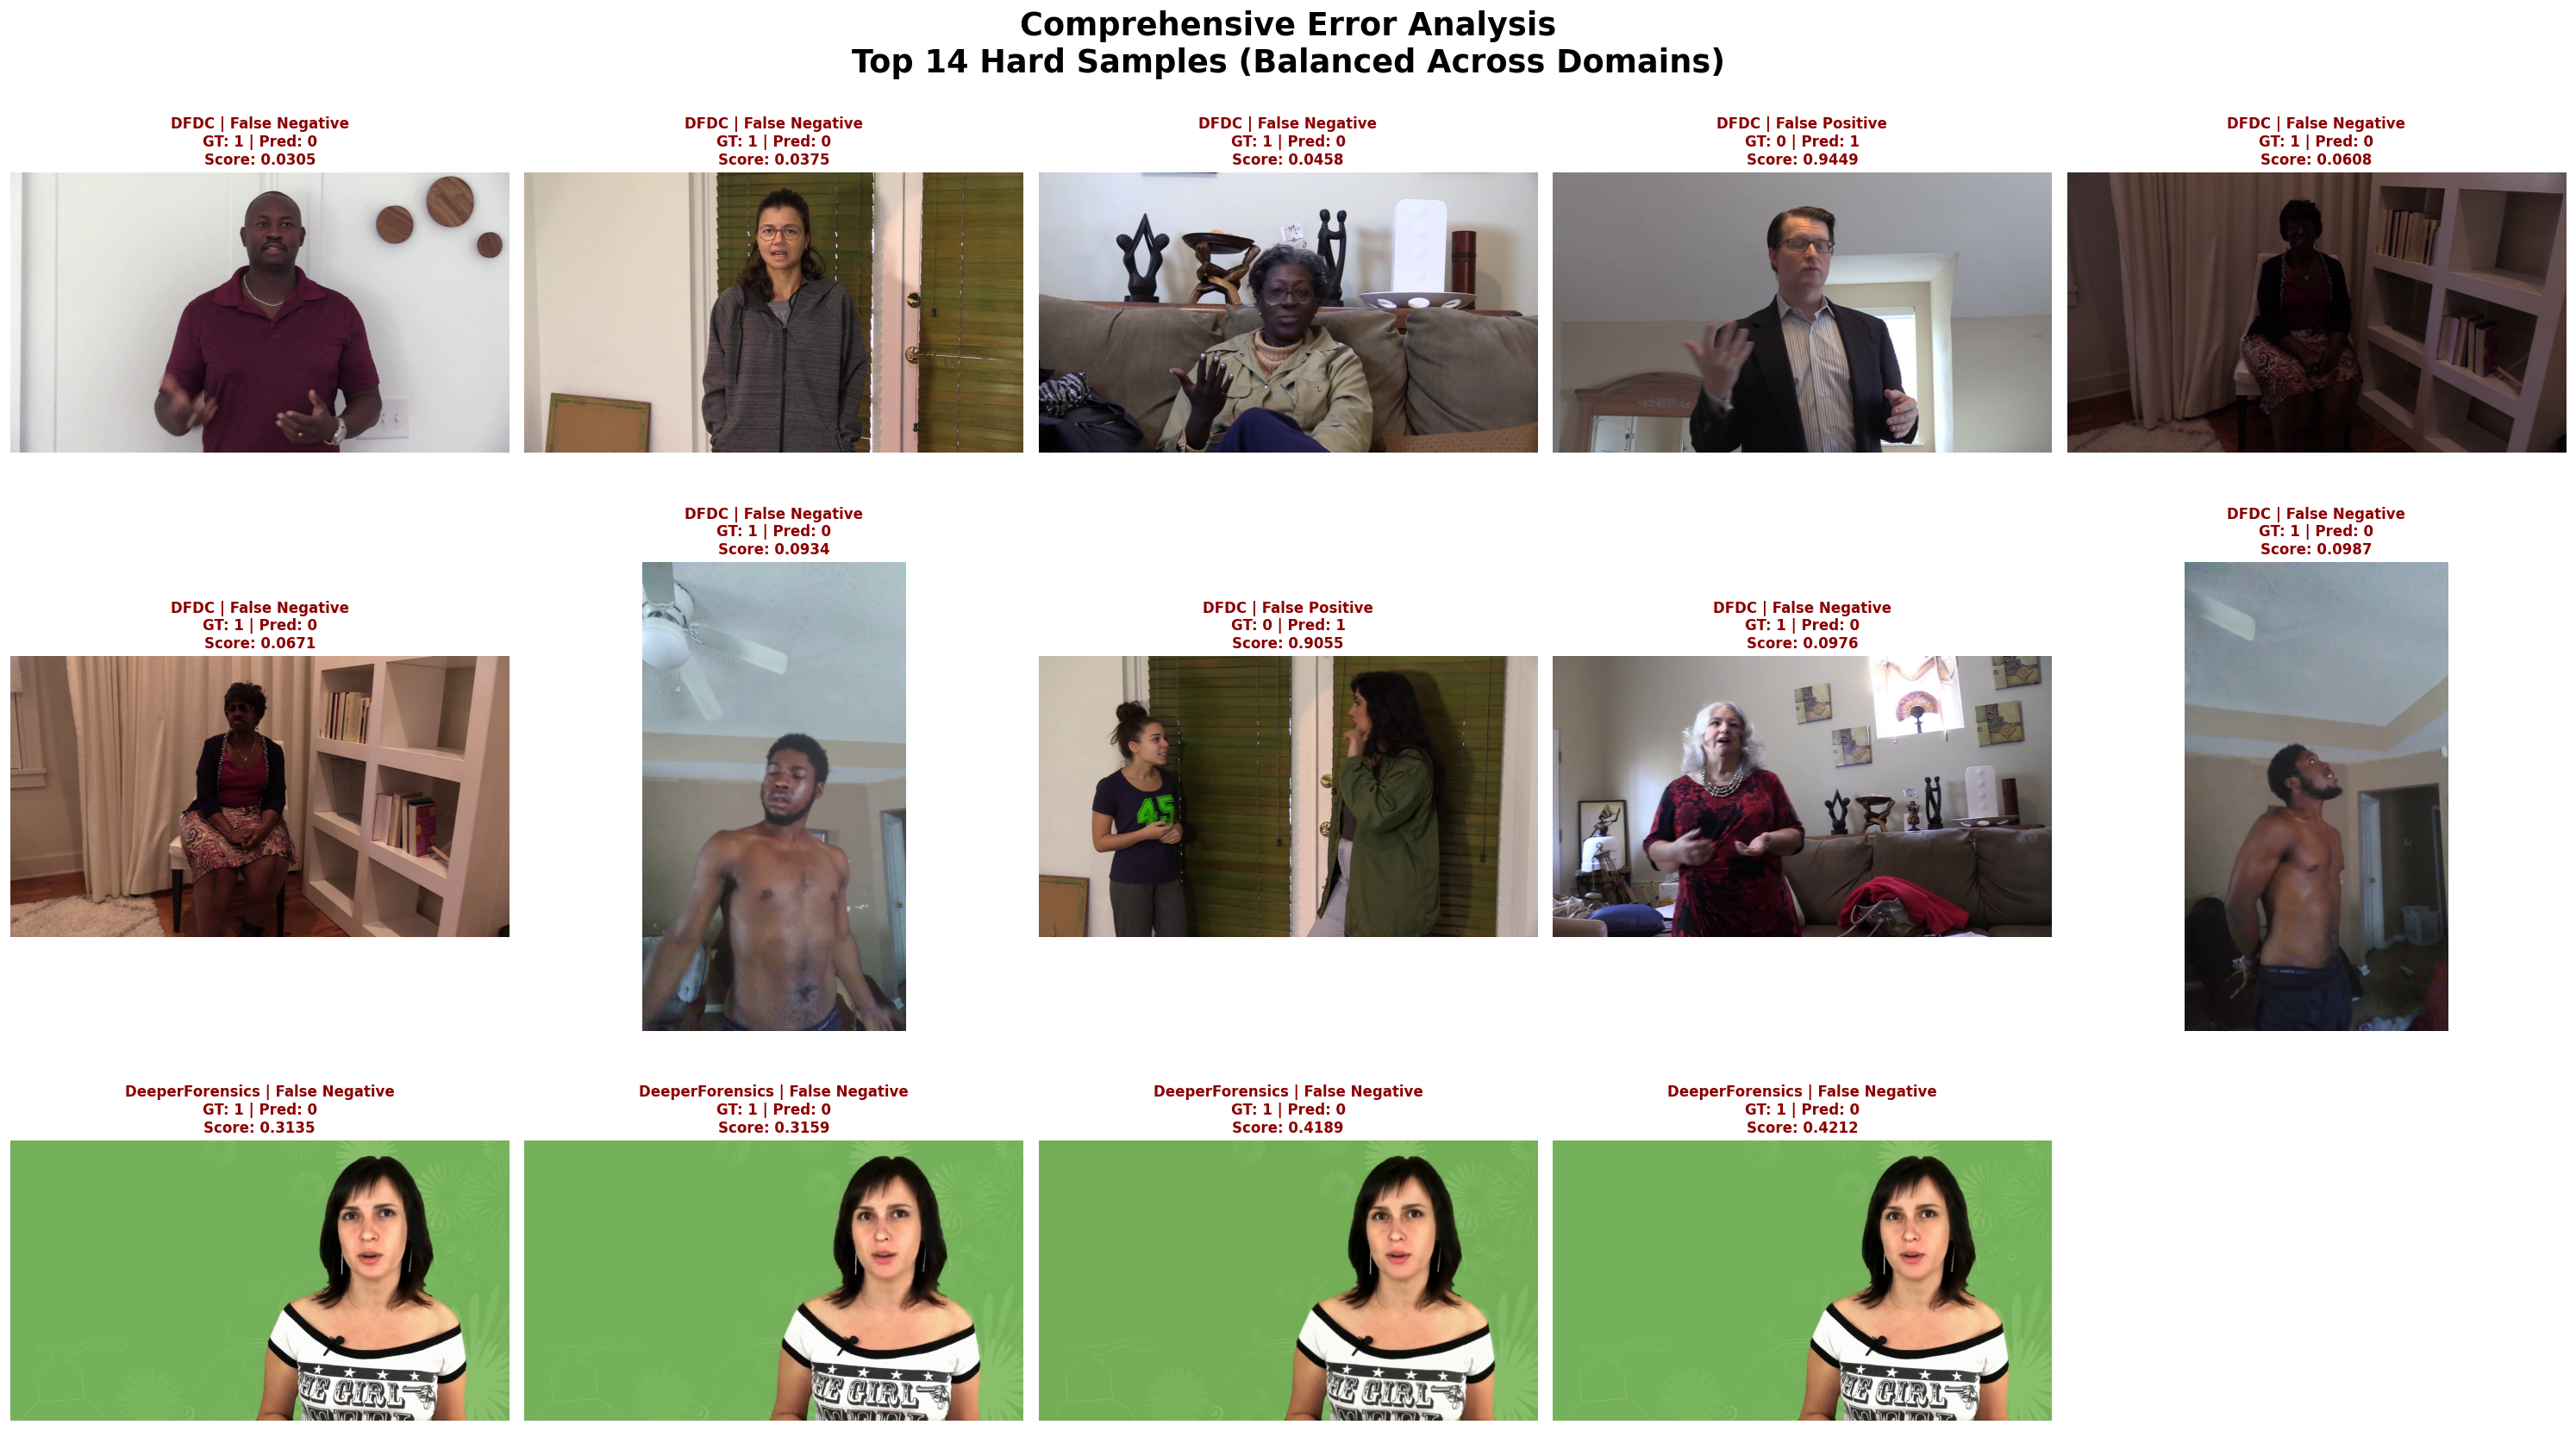

In [60]:
visualize_failure_grid(
    val_df,
    hard_indices,
    all_probs,
    all_labels,
    all_domains
)

In [64]:
import cv2
import numpy as np

def sample_frames(video_path, num_frames):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames < num_frames:
        indices = np.linspace(0, total_frames-1, total_frames).astype(int)
    else:
        indices = np.linspace(0, total_frames-1, num_frames).astype(int)
    
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (224, 224))
            frame = frame / 255.0
            frames.append(frame)
    
    cap.release()
    
    frames = np.array(frames)
    return frames

In [71]:
class DeepfakeDataset(Dataset):
    def __init__(self, df, frame_depth):
        self.df = df.reset_index(drop=True)
        self.frame_depth = frame_depth
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        video_path = self.df.loc[idx, 'path']
        label = self.df.loc[idx, 'class_label']
        
        frames = sample_frames(video_path, self.frame_depth)
        
        frames = torch.tensor(frames).permute(0, 3, 1, 2).float()
        label = torch.tensor(label).float()
        
        return frames, label

In [72]:
from torch.utils.data import DataLoader

def get_val_dataloader(frame_depth):
    val_dataset = DeepfakeDataset(val_df, frame_depth=frame_depth)
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=4,      # adjust to your GPU
        shuffle=False,
        num_workers=4
    )
    
    return val_loader

In [76]:
def evaluate_temporal_depth(model, dataloader):
    all_preds = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for videos, labels in dataloader:
            videos = videos.to(device)
            
            outputs = model(videos)
            
            # 🔥 FIX HERE
            if isinstance(outputs, tuple):
                outputs = outputs[0]   # take logits only
            
            probs = torch.sigmoid(outputs).cpu().numpy()
            
            all_preds.extend(probs.flatten())
            all_labels.extend(labels.numpy())
    
    auc = roc_auc_score(all_labels, all_preds)
    return auc

In [77]:
frame_depths = [8, 16, 24]
results = {}

for depth in frame_depths:
    print(f"\n🔬 Testing Temporal Depth: {depth} frames")
    
    val_loader = get_val_dataloader(frame_depth=depth)
    
    auc = evaluate_temporal_depth(model, val_loader)
    results[depth] = auc
    
    print(f"Temporal Depth: {depth} | AUC: {auc:.6f}")


🔬 Testing Temporal Depth: 8 frames


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb3bd88d5a0>
Traceback (most recent call last):
  File "/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1646, in _shutdown_workers
    if w.is_alive():
  File "/root/miniconda3/envs/py3.10/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb3bd88d5a0>
Traceback (most recent call last):
  File "/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/torch/u

KeyboardInterrupt: 

In [74]:
videos, labels = next(iter(val_loader))
videos = videos.to(device)

out = model(videos)
print(type(out))

<class 'tuple'>


In [75]:
print(len(out))

2


In [85]:
def evaluate_model(model, dataloader):
    all_preds = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for videos, labels in dataloader:
            videos = videos.to(device)
            
            outputs = model(videos)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            
            probs = torch.sigmoid(outputs)
            
            all_preds.extend(probs.cpu().numpy().flatten())
            all_labels.extend(labels.numpy())
    
    return roc_auc_score(all_labels, all_preds)

In [86]:
baseline_auc = evaluate_model(model, val_loader)
print("Baseline AUC:", baseline_auc)

Baseline AUC: 0.9983454137253049
